# Final thesis plots

Clean, publication-quality versions of the main oscillon results, all in one place.
Every panel is rendered inline **and** saved as a PDF (with a PNG mirror) in `GoodFigures/`.

**Conventions (applied to every panel below):**
- One *selection* cell with explicit lists of which parameters to plot.
- One *plot* cell ending in `save_fig(fig, NAME); plt.show()`.

**Index of panels:**
1. Scalar field at $r=0$ vs $t$ and vs shifted $\ln(a)$.
2. Four-panel paper diagnostics (`plot_paper_diagnostics`) for one chosen run.
3. Central density $\rho_c$ vs background density $\bar\rho$ — decoupling from the Hubble flow.
4. Compactness, weak-coupling condition and $g_2$ hyperbolicity (3-stack EFT diagnostics, $\ln(a)\in[2,3.5]$).

Further panels will be added on request, following the same pattern.

## 0 — Imports and output directory

In [55]:
import sys, os, re, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)

from core.grid import Grid
from core.spacing import CubicSpacing
from core.statevector import StateVector
from matter.scalarmatter_MG import ScalarMatter
from backgrounds.sphericalbackground import FlatSphericalBackground
from bssn.oscillondiagnostic import get_oscillon_diagnostic, plot_paper_diagnostics
from bssn.EFTdiagnostic import get_eft_diagnostic

DATA_DIR = os.path.join(os.environ.get("VSC_DATA", os.getcwd()), "oscillon_runs")
FIG_DIR  = Path(os.getcwd()) / "GoodFigures"
FIG_DIR.mkdir(exist_ok=True)

print(f"DATA_DIR = {DATA_DIR}")
print(f"FIG_DIR  = {FIG_DIR}")

DATA_DIR = /data/leuven/384/vsc38419/oscillon_runs
FIG_DIR  = /vsc-hard-mounts/leuven-user/384/vsc38419/0scillons/February26Oscillons/Feb26/RunningCode/DATA/GoodFigures


## 1 — Publication style and figure-saving helper

In [56]:
from numpy._core.numeric import False_


plt.rcParams.update({
    "font.family":      "serif",
    "mathtext.fontset": "cm",
    "figure.dpi":       120,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "axes.labelsize":   23,
    "axes.titlesize":   16,
    "xtick.labelsize":  12,
    "ytick.labelsize":  12,
    "legend.fontsize":  11,
    "lines.linewidth":  2.5,
    "axes.linewidth":   2,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "xtick.minor.width": 0.9,
    "ytick.minor.width": 0.9,
    "xtick.major.size":  5.0,
    "ytick.major.size":  5.0,
    "axes.grid":        False,
    "grid.alpha":       0.3,
})

def save_fig(fig, name):
    """Save fig as both PDF and PNG in GoodFigures/."""
    pdf_path = FIG_DIR / f"{name}.pdf"
    png_path = FIG_DIR / f"{name}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"  saved {pdf_path.name} and {png_path.name}")

## 2 — Alignment and grid parameters

All runs share the same physical grid and modified-gravity background; alignment shifts each
run's $\ln(a)$ axis so the last crossing of a per-amplitude compactness threshold sits at
`ALIGN_LNA`.

In [57]:
ALIGN_LNA      = 2.0
ALIGN_METHOD   = "last_cross"   # "min_C" or "last_cross"
LNA_MIN_SEARCH = 0.0

C_CROSS_LEVELS = {
    -0.02: 0.02,
    -0.05: 0.04,
    -0.1:  0.06,
    -0.5:  0.125,
}
C_CROSS_DEFAULT = 0.02

LN_A_COMP_MIN = 2.0
LN_A_COMP_MAX = 3.5

scalar_mu = 1
r_max     = 150
min_dr    = 1 / 16
max_dr    = 2
a_mg      = 0.2
b_mg      = 0.4
chi0      = 0.15

## 3 — Alignment helpers

In [58]:
def find_peak_lna(osc, lna_min=0.0):
    """Return ln(a) of the minimum compactness after lna_min."""
    C = osc["C"]
    ln_a = osc["ln_a"]
    mask = ln_a > lna_min
    if not np.any(mask):
        return np.nan
    idx = np.where(mask)[0]
    peak = idx[np.argmin(C[idx])]
    return ln_a[peak]

def find_last_crossing_lna(osc, level, lna_min=0.0):
    """Return ln(a) of the last time C crosses `level` (from above) after lna_min."""
    C = osc["C"]
    ln_a = osc["ln_a"]
    mask = ln_a > lna_min
    if not np.any(mask):
        return np.nan
    idx = np.where(mask)[0]
    C_sub = C[idx]
    ln_a_sub = ln_a[idx]
    above = C_sub > level
    crossings = np.where(above[:-1] & ~above[1:])[0]
    if len(crossings) == 0:
        return np.nan
    last = crossings[-1]
    frac = (level - C_sub[last+1]) / (C_sub[last] - C_sub[last+1])
    return ln_a_sub[last] * frac + ln_a_sub[last+1] * (1 - frac)

def compactness_in_window(shifted_ln_a, C, lo=LN_A_COMP_MIN, hi=LN_A_COMP_MAX):
    """Mean, min, max, std of C inside [lo, hi] on the *shifted* axis."""
    mask = (shifted_ln_a >= lo) & (shifted_ln_a <= hi)
    if not np.any(mask):
        return np.nan, np.nan, np.nan, np.nan
    c = C[mask]
    return np.mean(c), np.min(c), np.max(c), np.std(c)

def _key_sort(key):
    """Sort key for run-keys that may contain None (e.g. beta=None for linear coupling).

    Maps None -> +inf so linear runs sort after numeric beta values.
    """
    return tuple(float('inf') if v is None else v for v in key)

## 4 — Load all runs at the chosen resolution

Loads every run that matches the loading filters (default: $a_{\rm MG}=b_{\rm MG}=0$, $\Delta r = 1/24$),
computes/loads diagnostics, applies the alignment shift, and also stashes the central scalar field
$\phi(r=0,t)$ so plot 1 doesn't need to reload `solution.npy`.

In [59]:
######## LOADING FILTERS ########
FILTER_A_MG = 0       # None to load all
FILTER_B_MG = 0       # None to load all
FILTER_DR   = 1/24    # None to load all
############################

# Key now includes g2 so quadratic and g2-EFT runs with the same
# (lgb, mu, beta, amp, width) but different g2 don't overwrite each other.
all_runs = {}   # key = (lgb, mu, beta, amp, width, g2)

for run_dir in sorted(glob.glob(os.path.join(DATA_DIR, "lgb*"))):
    tag = os.path.basename(run_dir)
    if not os.path.exists(os.path.join(run_dir, "solution.npy")):
        continue

    m_lgb = re.search(r"lgb([0-9eE.+-]+)", tag)
    m_mu  = re.search(r"mu([0-9eE.+-]+)", tag)
    m_amp = re.search(r"_amp([0-9eE.+-]+)", tag)
    m_R   = re.search(r"_R([0-9eE.+-]+)", tag)
    if not m_lgb or not m_mu:
        continue
    lgb   = float(m_lgb.group(1))
    mu    = float(m_mu.group(1))
    amp   = float(m_amp.group(1)) if m_amp else -0.02
    width = float(m_R.group(1))   if m_R   else 3.0

    m_a = re.search(r"_a([0-9eE.+-]+)_b", tag)
    m_b = re.search(r"_b([0-9eE.+-]+)_amp", tag)
    tag_a = float(m_a.group(1)) if m_a else 0.2
    tag_b = float(m_b.group(1)) if m_b else 0.4

    m_dr = re.search(r"_dr([0-9eE.+-]+)", tag)
    tag_dr = float(m_dr.group(1)) if m_dr else 0.0625

    if FILTER_A_MG is not None and abs(tag_a - FILTER_A_MG) > 1e-10:
        continue
    if FILTER_B_MG is not None and abs(tag_b - FILTER_B_MG) > 1e-10:
        continue
    if FILTER_DR is not None and abs(tag_dr - FILTER_DR) > 1e-4:
        continue

    m_beta = re.search(r"quadratic_(\d+\.?\d*)", tag)
    if m_beta:
        beta = float(m_beta.group(1))
    elif re.search(r"_quadratic_g2", tag) or tag.endswith("_quadratic"):
        beta = 0.0
    else:
        beta = 250.0

    if "_linear" in tag:
        coupling = "linear"; beta = None
    elif m_beta:
        coupling = f"quadratic_{int(beta)}"
    else:
        coupling = "quadratic"

    # Extract g2: first from directory name, then from metadata, default 0.0
    g2_val = 0.0
    m_g2 = re.search(r"_g2([0-9eE.+-]+)", tag)
    if m_g2:
        g2_val = float(m_g2.group(1))
    else:
        meta_path = os.path.join(run_dir, "metadata.npz")
        if os.path.exists(meta_path):
            try:
                meta = dict(np.load(meta_path, allow_pickle=True))
                if "g2" in meta:
                    g2_val = float(meta["g2"])
            except Exception:
                pass

    # Grid must match the run that wrote solution.npy (notebook r_max/min_dr alone can differ).
    _meta_for_grid = os.path.join(run_dir, "metadata.npz")
    _meta_grid = dict(np.load(_meta_for_grid, allow_pickle=True)) if os.path.exists(_meta_for_grid) else {}
    run_r_max  = float(_meta_grid.get("r_max", r_max))
    run_min_dr = float(_meta_grid.get("min_dr", tag_dr))
    run_max_dr = float(_meta_grid.get("max_dr", max_dr))

    sol = np.load(os.path.join(run_dir, "solution.npy"))
    t   = np.load(os.path.join(run_dir, "t.npy"))

    matter_i  = ScalarMatter(scalar_mu, mu)
    sv_i      = StateVector(matter_i)
    spacing_i = CubicSpacing(**CubicSpacing.get_parameters(run_r_max, run_min_dr, run_max_dr))
    grid_i    = Grid(spacing_i, sv_i)
    bg_i      = FlatSphericalBackground(grid_i.r)

    diag_path = os.path.join(run_dir, "diagnostics.npz")
    if os.path.exists(diag_path):
        osc = dict(np.load(diag_path, allow_pickle=True))
    else:
        params = (lgb, a_mg, b_mg, chi0, coupling)
        osc = get_oscillon_diagnostic(
            sol, t, grid_i, bg_i,
            ScalarMatter(scalar_mu, mu),
            params, surface_threshold=0.05, r_max_diag=100.0,
        )
        np.savez(diag_path, **osc)

    # Stash central scalar field phi(r=0, t)
    N_grid   = len(grid_i.r)
    NUM_VARS = sol.shape[1] // N_grid
    phi_c    = sol[:, 12 * N_grid].copy()

    if ALIGN_METHOD == "last_cross":
        cross_level = C_CROSS_LEVELS.get(amp, C_CROSS_DEFAULT)
        anchor_lna  = find_last_crossing_lna(osc, level=cross_level, lna_min=LNA_MIN_SEARCH)
    else:
        anchor_lna  = find_peak_lna(osc, lna_min=LNA_MIN_SEARCH)
    shift = ALIGN_LNA - anchor_lna if not np.isnan(anchor_lna) else 0.0
    shifted_ln_a = osc["ln_a"] + shift

    C_mean, C_min, C_max, C_std = compactness_in_window(shifted_ln_a, osc["C"])

    key = (lgb, mu, beta, amp, width, g2_val)
    all_runs[key] = dict(
        osc=osc, t=t, phi_c=phi_c, tag=tag,
        lgb=lgb, mu=mu, beta=beta, coupling=coupling, amp=amp, width=width, g2=g2_val,
        run_dir=run_dir, dr=tag_dr,
        run_r_max=run_r_max, run_min_dr=run_min_dr, run_max_dr=run_max_dr,
        shift=shift, shifted_ln_a=shifted_ln_a,
        C_mean=C_mean, C_min=C_min, C_max=C_max, C_std=C_std,
    )

    beta_str = f"beta={int(beta)}" if beta is not None else "linear"
    if np.isnan(C_mean):
        print(f"  lgb={lgb:6.1f}, mu={mu}, {beta_str:>10s}, A={amp}, R={width}, g2={g2_val:g}  "
              f"shift={shift:+.3f}  C: no data in window  ({len(t)} steps)")
    else:
        print(f"  lgb={lgb:6.1f}, mu={mu}, {beta_str:>10s}, A={amp}, R={width}, g2={g2_val:g}  "
              f"shift={shift:+.3f}  C={C_mean:.4e} [{C_min:.4e}, {C_max:.4e}]  ({len(t)} steps)")
    del sol

print(f"\nTotal: {len(all_runs)} run(s) loaded and aligned")

  lgb=  -1.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.538  C=7.1395e-03 [4.3339e-03, 1.4466e-02]  (1000 steps)
  lgb=  -2.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.536  C=7.0535e-03 [4.2847e-03, 1.3609e-02]  (1000 steps)
  lgb=  -3.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.531  C=6.9746e-03 [4.2228e-03, 1.3554e-02]  (1000 steps)
  lgb=  -4.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.526  C=6.8850e-03 [4.1713e-03, 1.3361e-02]  (1000 steps)
  lgb=  -5.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.524  C=6.8001e-03 [4.1293e-03, 1.3226e-02]  (1000 steps)
  lgb=  -6.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.490  C=6.7319e-03 [4.1234e-03, 1.2932e-02]  (1000 steps)
  lgb=  -7.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.480  C=6.6470e-03 [4.0823e-03, 1.2883e-02]  (1000 steps)
  lgb=  -8.0, mu=0.08,     beta=0, A=-0.02, R=3.0, g2=20  shift=+0.475  C=6.5698e-03 [4.0308e-03, 1.2720e-02]  (1000 steps)
  lgb=  

## 5 — Parameter catalogue

Overview of which parameters are available in `all_runs` after filtering.

In [60]:
all_lgb   = sorted(set(k[0] for k in all_runs))
all_mu    = sorted(set(k[1] for k in all_runs))
all_beta  = sorted(set(k[2] for k in all_runs if k[2] is not None))
has_linear = any(k[2] is None for k in all_runs)
all_amp   = sorted(set(k[3] for k in all_runs))
all_width = sorted(set(k[4] for k in all_runs))
all_g2    = sorted(set(k[5] for k in all_runs))
all_couplings = sorted(set(d["coupling"] for d in all_runs.values()))

print(f"runs loaded:      {len(all_runs)}")
print(f"lambda_GB values: {all_lgb}")
print(f"mu values:        {all_mu}")
print(f"beta values:      {all_beta}" + ('  (+ linear runs present)' if has_linear else ''))
print(f"amplitude values: {all_amp}")
print(f"width values:     {all_width}")
print(f"g2 values:        {all_g2}")
print(f"couplings:        {all_couplings}")

print("\nLoaded keys (lgb, mu, beta, amp, width, g2):")
header = (f"  {'lgb':>6s}  {'mu':>5s}  {'beta':>5s}  {'amp':>6s}  {'R':>4s}  {'g2':>6s}  "
          f"{'coupling':<14s}  {'shift':>7s}  {'C_mean':>10s}")
print(header)
print("  " + "-" * (len(header) - 2))
for k in sorted(all_runs.keys(), key=_key_sort):
    d = all_runs[k]
    beta_s = "lin" if k[2] is None else f"{k[2]:g}"
    cmean  = "nan" if np.isnan(d['C_mean']) else f"{d['C_mean']:.3e}"
    print(f"  {k[0]:>6g}  {k[1]:>5g}  {beta_s:>5s}  {k[3]:>6g}  {k[4]:>4g}  {k[5]:>6g}  "
          f"{d['coupling']:<14s}  {d['shift']:>+7.3f}  {cmean:>10s}")

runs loaded:      88
lambda_GB values: [-9.0, -8.0, -7.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
mu values:        [0.08]
beta values:      [0.0]  (+ linear runs present)
amplitude values: [-1.0, -0.5, -0.1, -0.05, -0.02]
width values:     [3.0]
g2 values:        [-10.0, -5.0, -4.0, -3.0, -2.0, -1.0, -0.5, 0.0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 10.0, 20.0, 25.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 40.0, 50.0]
couplings:        ['linear', 'quadratic', 'quadratic_0']

Loaded keys (lgb, mu, beta, amp, width, g2):
     lgb     mu   beta     amp     R      g2  coupling          shift      C_mean
  -------------------------------------------------------------------------------
      -9   0.08      0   -0.02     3      20  quadratic_0      +0.474   6.481e-03
      -8   0.08      0   -0.02     3      20  quadratic_0      +0.475   6.570e-03
      -7   0.08      0   -0.02     3      20  quadratic_0      +0.480   6.647e-03
      -6   0.08      

## 6 — `select_runs` helper

One-liner for the per-panel selection cells. Any argument left as `None` matches all values.

In [61]:
def select_runs(lgb=None, mu=None, beta=None, amp=None, width=None, g2=None, coupling=None):
    """Return list of keys in all_runs whose fields are in the given allowed lists.

    Pass a single value or a list; None = no filter on that dimension.
    Keys are 6-tuples: (lgb, mu, beta, amp, width, g2).
    """
    def _norm(v):
        if v is None: return None
        return v if isinstance(v, (list, tuple, set)) else [v]

    lgb, mu, beta = _norm(lgb), _norm(mu), _norm(beta)
    amp, width, g2 = _norm(amp), _norm(width), _norm(g2)
    coupling = _norm(coupling)

    def _in(x, allowed): return allowed is None or x in allowed

    matches = [
        k for k, d in all_runs.items()
        if _in(k[0], lgb) and _in(k[1], mu) and _in(k[2], beta)
        and _in(k[3], amp) and _in(k[4], width) and _in(k[5], g2)
        and _in(d["coupling"], coupling)
    ]
    return sorted(matches, key=_key_sort)

## Panel 1 — Scalar field at $r=0$

Left subplot: $\phi(r=0)$ vs simulation time $t\ [1/m]$.<br>
Right subplot: $\phi(r=0)$ vs aligned $\ln(a)$.

Edit `PLOT1_*` below to pick which runs go on the figure.

In [64]:
### --- Panel 1 selection (edit me) ---
PLOT1_KEYS = select_runs(
    lgb   = [-5, 0, 5],
    mu    = [0.08],
    beta  = [0],
    amp   = [-0.02],
    width = [3.0],
    g2= [0]
)
PLOT1_NAME = "phi_center_evolution"

print(f"{len(PLOT1_KEYS)} run(s) selected for Panel 1:")
for k in PLOT1_KEYS:
    print(" ", k, " coupling=", all_runs[k]["coupling"])

2 run(s) selected for Panel 1:
  (0.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling= quadratic
  (5.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling= quadratic_0


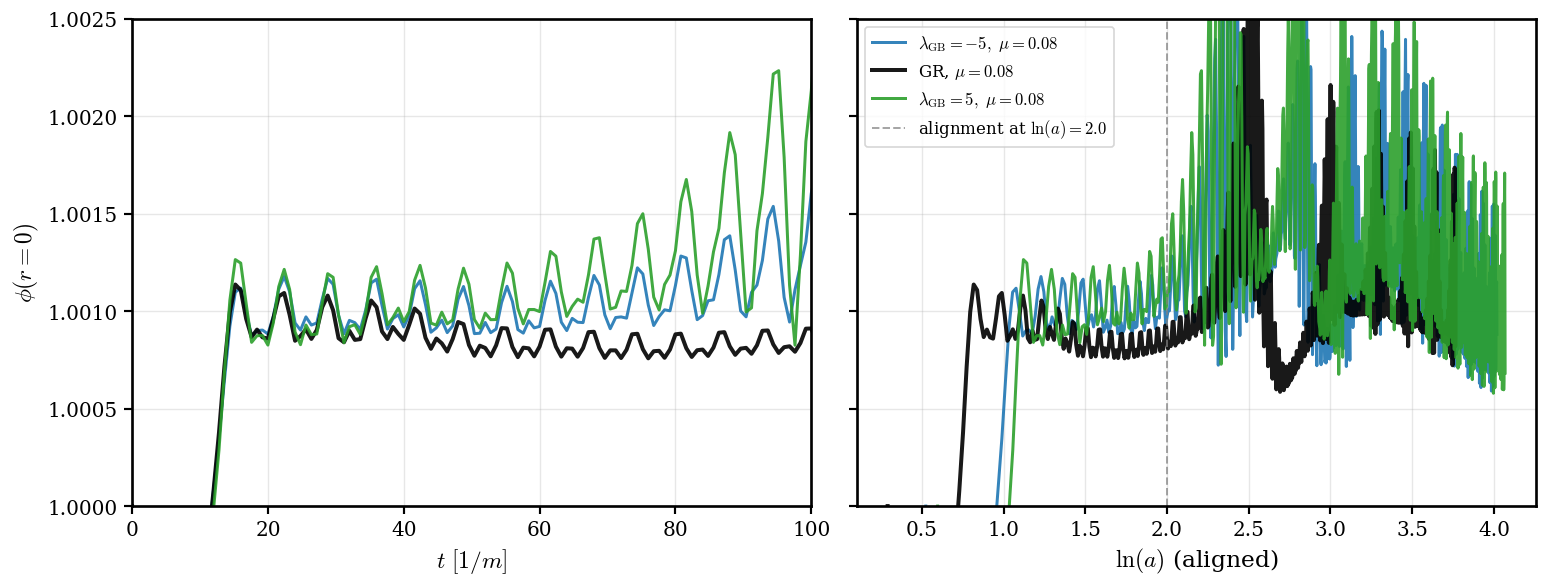

In [26]:
fig, (ax_t, ax_lna) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
cmap = plt.cm.tab10

for i, key in enumerate(PLOT1_KEYS):
    data = all_runs[key]
    lgb, mu, beta, amp, width, g2 = key

    if lgb == 0.0:
        label = rf"GR, $\mu={mu}$"
    else:
        beta_s = "" if (beta is None or beta == 0) else rf",\ \beta={int(beta)}"
        label  = rf"$\lambda_{{\rm GB}}={lgb:g},\ \mu={mu}{beta_s}$"

    color = "k" if lgb == 0.0 else cmap(i % 10)
    lw    = 2.4 if lgb == 0.0 else 1.8

    ax_t.plot(data["t"], data["phi_c"], color=color, lw=lw, label=label, alpha=0.9)
    ax_lna.plot(data["shifted_ln_a"], data["phi_c"], color=color, lw=lw, label=label, alpha=0.9)

ax_lna.axvline(ALIGN_LNA, color="grey", ls="--", lw=1.2, alpha=0.7,
               label=rf"alignment at $\ln(a)={ALIGN_LNA}$")

ax_t.set_xlabel(r"$t\ [1/m]$")
ax_t.set_ylabel(r"$\phi(r=0)$")
ax_t.set_ylim(1,1.0025)
ax_t.set_xlim(0,100)
#ax_t.set_title("Central scalar field vs physical time")

ax_lna.set_xlabel(r"$\ln(a)$ (aligned)")
#ax_lna.set_title("Central scalar field vs aligned $\\ln(a)$")

ax_lna.legend(fontsize=10, loc="best", frameon=True)
fig.tight_layout()
#save_fig(fig, PLOT1_NAME)
plt.show()

## Panel 2 — Paper diagnostics for one run

The four standard diagnostic panels from `bssn.oscillondiagnostic.plot_paper_diagnostics`
(density contrast, central density, mass & radius, compactness) plotted on the **shifted**
$\ln(a)$ axis for a single chosen run.

Edit `PLOT2_KEY` and `PLOT2_NAME` below.

In [65]:
### --- Panel 2 selection (edit me) ---
# key format: (lgb, mu, beta, amp, width, g2)
PLOT2_KEY  = (0, 0.08, 0, -0.02, 3.0, 0)
PLOT2_NAME = "paper_diagnostics_GR_amp-0.02"

if PLOT2_KEY not in all_runs:
    print(f"Key {PLOT2_KEY} not found in all_runs.")
    print("Available keys:")
    for k in sorted(all_runs.keys(), key=_key_sort):
        print(" ", k)
else:
    print(f"Selected: {PLOT2_KEY}")
    print(f"  tag      = {all_runs[PLOT2_KEY]['tag']}")
    print(f"  coupling = {all_runs[PLOT2_KEY]['coupling']}")
    print(f"  shift    = {all_runs[PLOT2_KEY]['shift']:+.3f}")

Selected: (0, 0.08, 0, -0.02, 3.0, 0)
  tag      = lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_g20
  coupling = quadratic
  shift    = +0.093


<>:68: SyntaxWarning: invalid escape sequence '\l'
<>:68: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1449881/3205205728.py:68: SyntaxWarning: invalid escape sequence '\l'
  """


  saved paper_diagnostics_GR_amp-0.02.pdf and paper_diagnostics_GR_amp-0.02.png


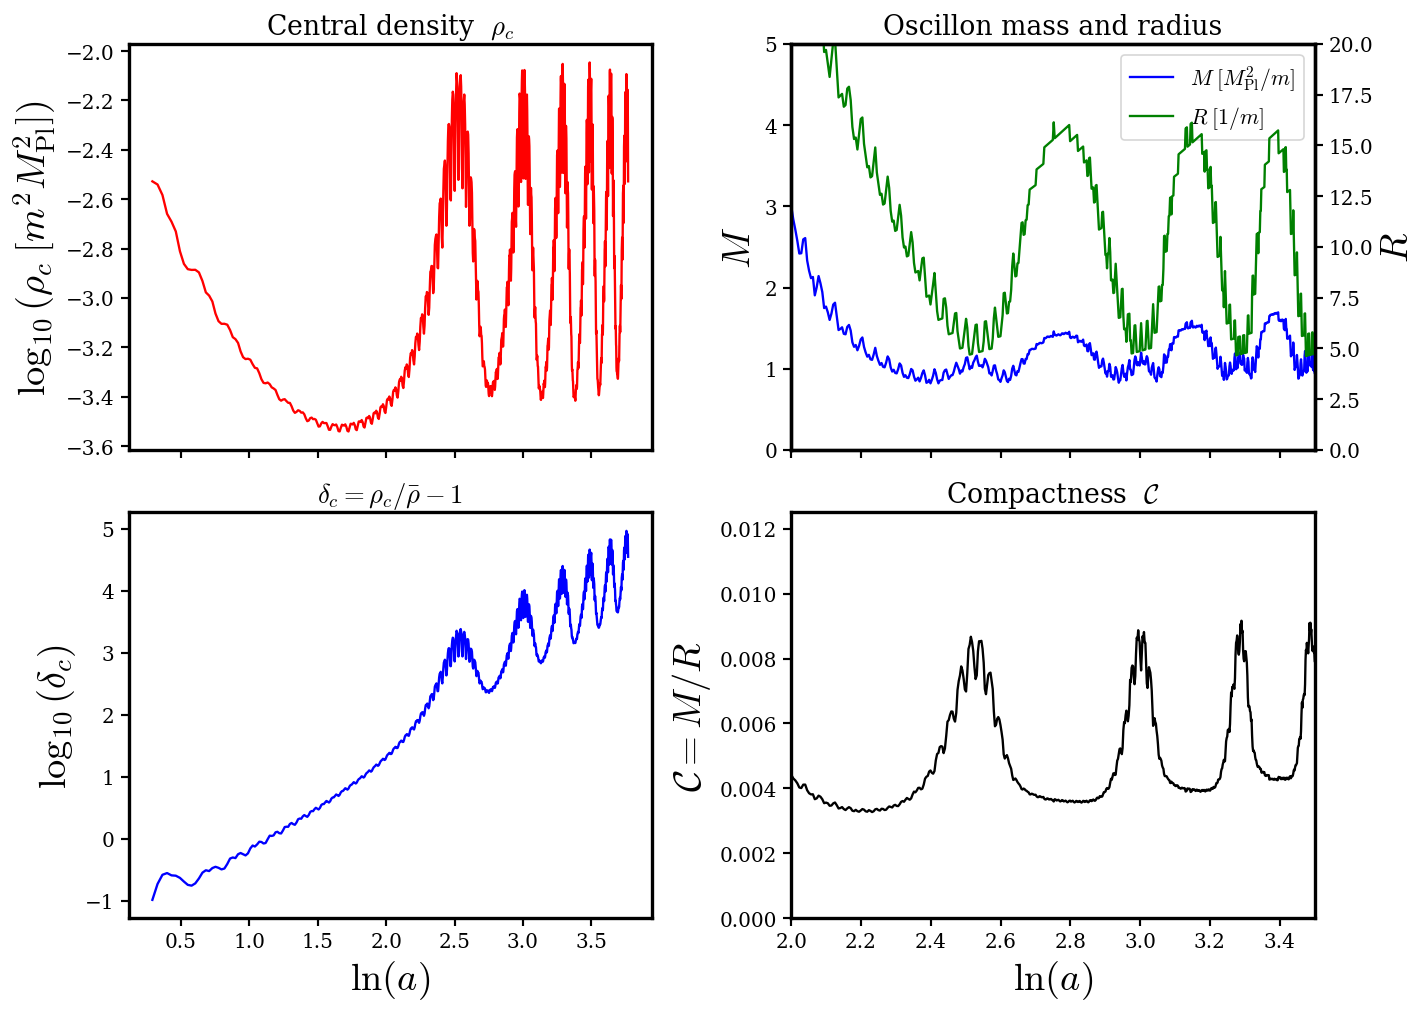

In [53]:
run = all_runs[PLOT2_KEY]
lgb_i, mu_i, beta_i, amp_i, width_i, g2_i = PLOT2_KEY

osc_shifted = {**run["osc"], "ln_a": run["shifted_ln_a"]}

# Custom 2x2 layout (re-arranged from plot_paper_diagnostics):
#   [0,0] log10(rho_c)   [0,1] M and R   (column 1 starts at ln(a)=2)
#   [1,0] log10(delta_c) [1,1] C         (column 1 starts at ln(a)=2)
# Columns share x via sharex='col' so stacked panels have identical x ranges.
x       = osc_shifted["ln_a"]
delta_c = osc_shifted["delta_c"]
rho_c   = osc_shifted["rho_c"]
M_arr   = osc_shifted["M"]
R_arr   = osc_shifted["R"]
C_arr   = osc_shifted["C"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex="col")

# [0,0] central density rho_c
ax = axes[0, 0]
pos_rho = rho_c > 0
y_rho = np.full_like(rho_c, np.nan)
y_rho[pos_rho] = np.log10(rho_c[pos_rho])
ax.plot(x, y_rho, "r-", lw=1.4)
ax.set_ylabel(r"$\log_{10}(\rho_c \; [m^2 M_{\rm Pl}^2])$")
ax.set_title(r"Central density  $\rho_c$")
#ax.grid(True, alpha=0.3)

# [0,1] oscillon mass and radius (starts at ln(a)=2)
ax_mr = axes[0, 1]
ax_mr.plot(x, M_arr, "b-", lw=1.4, label=r"$M \; [M_{\rm Pl}^2/m]$")
ax_mr_r = ax_mr.twinx()
ax_mr_r.plot(x, R_arr, "g-", lw=1.4, label=r"$R \; [1/m]$")
ax_mr.set_ylabel(r"$M$", color="black")
ax_mr_r.set_ylabel(r"$R$", color="black")
ax_mr_r.set_ylim(0,20)
ax_mr.set_ylim(0,5)
ax_mr.set_title("Oscillon mass and radius")
lines1, labels1 = ax_mr.get_legend_handles_labels()
lines2, labels2 = ax_mr_r.get_legend_handles_labels()
ax_mr.legend(lines1 + lines2, labels1 + labels2, fontsize=13, loc="best")
#ax_mr.grid(True, alpha=0.3)

# [1,0] density contrast delta_c
ax = axes[1, 0]
pos = delta_c > 0
y_d = np.full_like(delta_c, np.nan)
y_d[pos] = np.log10(delta_c[pos])
ax.plot(x, y_d, "b-", lw=1.4)
ax.set_xlabel(r"$\ln(a)$")
ax.set_ylabel(r"$\log_{10}(\delta_c)$")
ax.set_title(r"$\delta_c = \rho_c / \bar\rho - 1$")
#ax.grid(True, alpha=0.3)

# [1,1] compactness C (starts at ln(a)=2)
ax = axes[1, 1]
ax.plot(x, C_arr, "k-", lw=1.4)
ax.set_xlabel(r"$\ln(a)$")
ax.set_ylabel(r"$\mathcal{C} = M/R$")
ax.set_title(r"Compactness  $\mathcal{C}$")
ax.set_ylim(0, 1.25e-2)
#ax.grid(True, alpha=0.3)

# x-axis limits per column (column 1 starts at ln(a)=2). sharex='col' propagates.
axes[0, 1].set_xlim(2.0, 3.5)

beta_s = "linear" if beta_i is None else rf"\beta={int(beta_i)}"
"""
fig.suptitle(
    rf"$\lambda_{{\rm GB}}={lgb_i:g},\ \mu={mu_i},\ {beta_s},\ A={amp_i},\ R={width_i}$",
    fontsize=13,)
"""
fig.tight_layout(rect=[0, 0, 1, 0.95])
save_fig(fig, PLOT2_NAME)
plt.show()

## Panel 3 — Central vs background density (decoupling from the Hubble flow)

For each selected run, $\log_{10}\rho_c$ (solid) and $\log_{10}\bar\rho$ (dashed) vs aligned $\ln(a)$.
Where $\rho_c$ stops tracking $\bar\rho$ the configuration has decoupled from the Hubble flow.

In [67]:
### --- Panel 3 selection (edit me) ---
PLOT3_KEYS = select_runs(
    lgb   = [0],
    mu    = [0.08],
    beta  = [0],
    amp   = [-0.02],
    width = [3.0],
    g2 = [0]
)
PLOT3_NAME = "rho_c_vs_rho_bar"

print(f"{len(PLOT3_KEYS)} run(s) selected for Panel 3:")
for k in PLOT3_KEYS:
    print(" ", k, " coupling=", all_runs[k]["coupling"])

1 run(s) selected for Panel 3:
  (0.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling= quadratic


  saved rho_c_vs_rho_bar.pdf and rho_c_vs_rho_bar.png


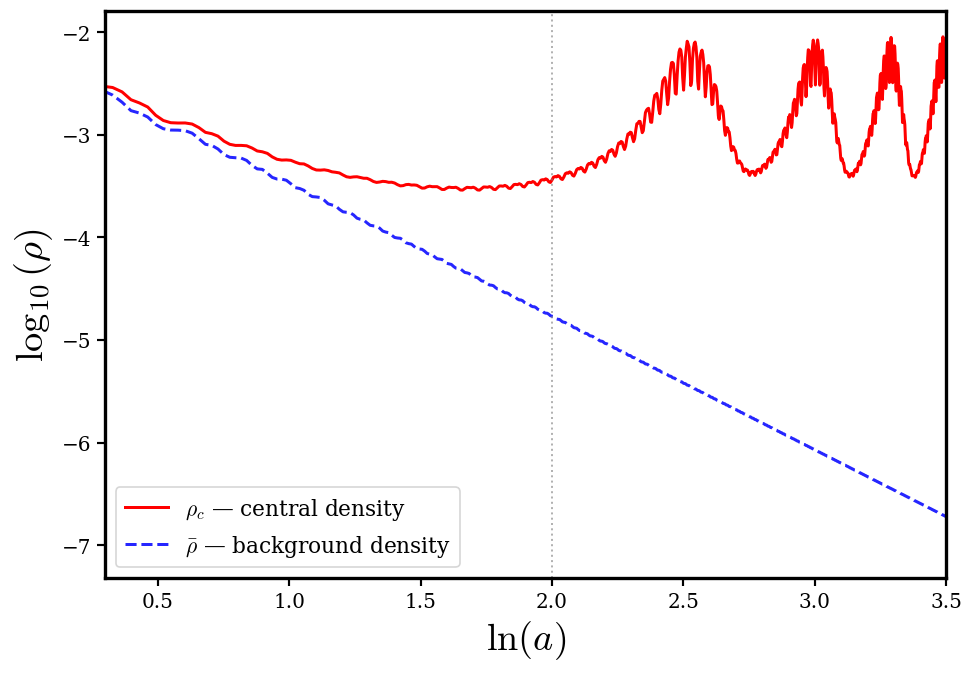

In [54]:
fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
cmap = plt.cm.tab10
single_run = (len(PLOT3_KEYS) == 1)

for i, key in enumerate(PLOT3_KEYS):
    data = all_runs[key]
    osc  = data["osc"]
    lgb, mu, beta, amp, width, g2 = key

    if "rho_bar" not in osc:
        print(f"  skipping {key}: rho_bar not in diagnostics")
        continue

    ln_a = data["shifted_ln_a"]
    rc   = np.asarray(osc["rho_c"])
    rb   = np.asarray(osc["rho_bar"])

    pos_c = rc > 0
    pos_b = rb > 0

    if single_run:
        color_c, color_b = "r", "b"
        lbl_c = r"$\rho_c$ — central density"
        lbl_b = r"$\bar{\rho}$ — background density"
    else:
        color_c = cmap(i % 10)
        color_b = color_c
        beta_s  = "" if (beta is None or beta == 0) else rf",\ \beta={int(beta)}"
        if lgb == 0.0:
            run_lbl = rf"GR, $\mu={mu}$"
        else:
            run_lbl = rf"$\lambda_{{\rm GB}}={lgb:g},\ \mu={mu}{beta_s}$"
        lbl_c = rf"$\rho_c$ (central density) ({run_lbl})"
        lbl_b = rf"$\bar\rho$ (background density) ({run_lbl})"

    ax.plot(ln_a[pos_c], np.log10(rc[pos_c]),
            color=color_c, lw=1.8, label=lbl_c)
    ax.plot(ln_a[pos_b], np.log10(rb[pos_b]),
            color=color_b, lw=1.8, ls="--", alpha=0.85, label=lbl_b)

ax.axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)

ax.set_xlabel(r"$\ln(a)$")
ax.set_ylabel(r"$\log_{10}(\rho)$")
ax.set_xlim(0.3,3.5)
#ax.set_title(r"Central density $\rho_c$ vs background $\bar{\rho}$")
ax.legend(fontsize=13, loc="best", frameon=True)
save_fig(fig, PLOT3_NAME)
plt.show()

## Panel 4 — Compactness, weak-coupling and $g_2$ hyperbolicity

Three stacked panels sharing the x-axis (aligned $\ln(a)$, fixed to $[2,\,3.5]$):
1. Compactness $\mathcal{C}$
2. Weak-coupling condition $\max_r \sqrt{|\lambda'|}\,L^{-1}$ (and $\sqrt{|g_2|}\,\tilde L^{-1}$ dashed where $g_2 \neq 0$)
3. $g_2$ hyperbolicity: $\min_r$ of $\det(g^{\rm eff}_{\mu\nu})/\det(g_{\mu\nu})$

GR (`lgb=0, g2=0`) is drawn as a thick black line. EFT diagnostics are computed (and cached
on disk) only for the selected runs. Set `FORCE_EFT_RECOMPUTE = True` to overwrite the
cached `eft_diagnostics.npz`.

In [71]:
### --- Panel 4 selection (edit me) ---
PLOT4_KEYS = select_runs(
    lgb   = [0],
    mu    = [0.08],
    beta  = [0],
    amp   = [-0.02],
    width = [3.0],
    g2    = [0, 10, 20],
)
PLOT4_NAME = "rho_C_WCC_hyp"

R_WCC_MAX           = 100.0   # only consider r in (0, R_WCC_MAX] for WCC / hyperbolicity maxima
FORCE_EFT_RECOMPUTE = False   # True = ignore any cached eft_diagnostics.npz and recompute

print(f"{len(PLOT4_KEYS)} run(s) selected for Panel 4:")
for k in PLOT4_KEYS:
    print(" ", k, " coupling=", all_runs[k]["coupling"], " g2=", k[5])

# Compute / load EFT diagnostics only for the selected runs
for k in PLOT4_KEYS:
    d = all_runs[k]
    if "eft" in d and not FORCE_EFT_RECOMPUTE:
        continue
    run_dir  = d["run_dir"]
    eft_path = os.path.join(run_dir, "eft_diagnostics.npz")
    if os.path.exists(eft_path) and not FORCE_EFT_RECOMPUTE:
        d["eft"] = dict(np.load(eft_path, allow_pickle=True))
        print(f"  [EFT] loaded cache for {d['tag']}")
    else:
        sol_i    = np.load(os.path.join(run_dir, "solution.npy"))
        matter_i = ScalarMatter(scalar_mu, d["mu"])
        sv_i     = StateVector(matter_i)
        spacing_i = CubicSpacing(**CubicSpacing.get_parameters(
            d["run_r_max"], d["run_min_dr"], d["run_max_dr"]))
        grid_i   = Grid(spacing_i, sv_i)
        bg_i     = FlatSphericalBackground(grid_i.r)
        lgb_k, mu_k, beta_k, amp_k, width_k, g2_k = k
        params = (lgb_k, a_mg, b_mg, chi0, d["coupling"], g2_k)
        eft = get_eft_diagnostic(
            sol_i, d["t"], grid_i, bg_i,
            ScalarMatter(scalar_mu, d["mu"]),
            params,
        )
        np.savez(eft_path, **eft)
        d["eft"] = eft
        del sol_i
        verb = "recomputed" if FORCE_EFT_RECOMPUTE else "computed"
        print(f"  [EFT] {verb} & cached for {d['tag']}")

3 run(s) selected for Panel 4:
  (0.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling= quadratic  g2= 0.0
  (0.0, 0.08, 0.0, -0.02, 3.0, 10.0)  coupling= quadratic  g2= 10.0
  (0.0, 0.08, 0.0, -0.02, 3.0, 20.0)  coupling= quadratic  g2= 20.0
  [EFT] loaded cache for lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_g210


  saved rho_C_WCC_hyp.pdf and rho_C_WCC_hyp.png


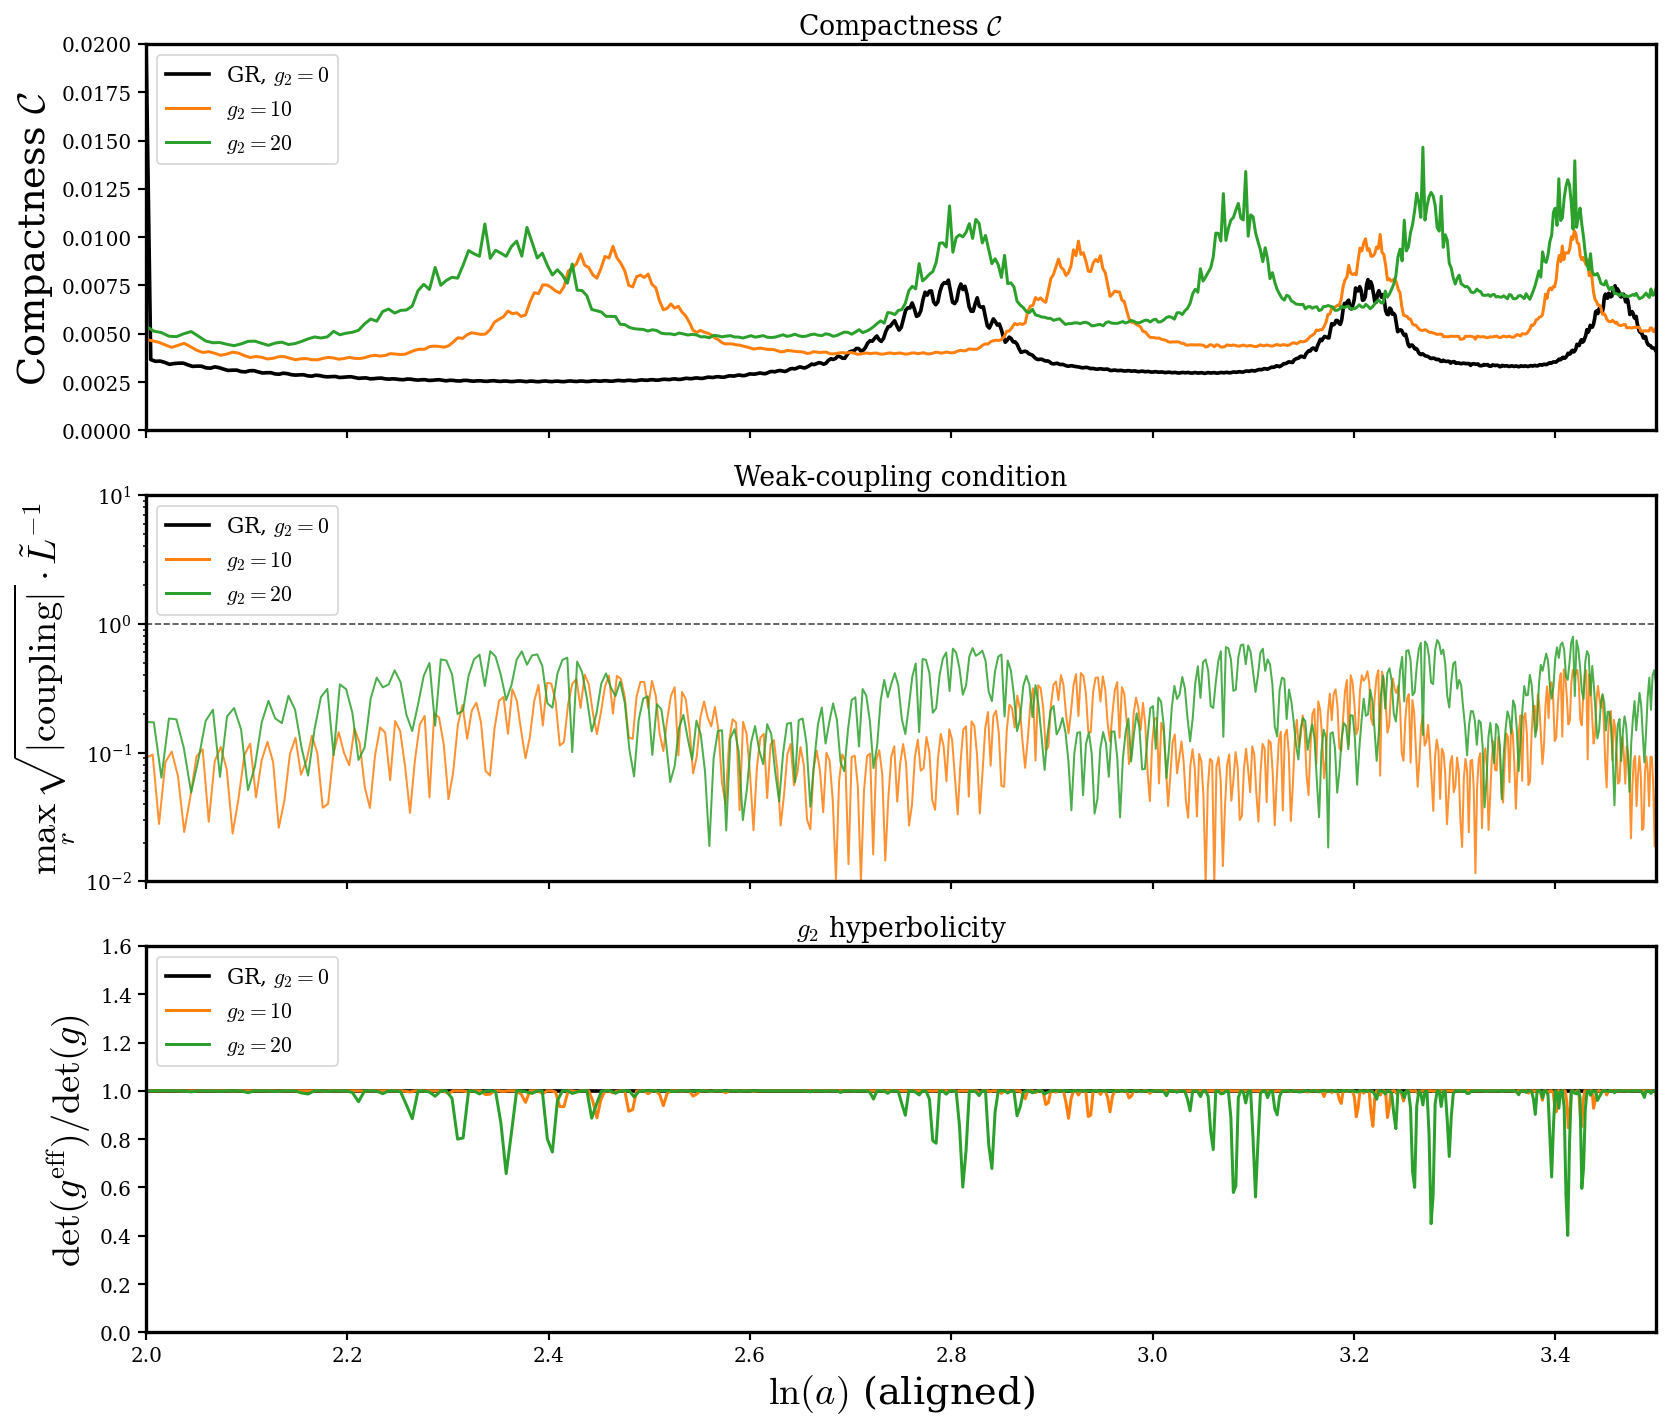

In [93]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
cmap = plt.cm.tab10

if len(PLOT4_KEYS) == 0:
    print("No keys selected for Panel 4.")
else:
    first = all_runs[PLOT4_KEYS[0]]
    r0    = first["eft"]["r"] if ("eft" in first) else None
    r_mask = (r0 > 0) & (r0 <= R_WCC_MAX) if r0 is not None else None

    for i, key in enumerate(PLOT4_KEYS):
        run = all_runs[key]
        osc = run["osc"]
        eft = run.get("eft", None)
        lgb, mu, beta, amp, width, g2 = key

        is_gr = (lgb == 0.0 and g2 == 0.0)
        beta_str = rf", \beta={int(beta)}" if (beta is not None and beta != 250) else ""
        g2_str   = rf"g_2={g2:g}"
        if is_gr:
            label = rf"GR, ${g2_str}$"
        else:
            label = rf"${g2_str}$"
        color = "k" if is_gr else cmap(i % 10)
        lw    = 2.2 if is_gr else 1.8

        x = run["shifted_ln_a"]

        # Panel 0: compactness
        axes[0].plot(x, osc["C"], color=color, lw=lw, label=label)

        # Panel 1: weak-coupling conditions (need eft data)
        if eft is not None and r_mask is not None:
            wc_lam = np.nanmax(eft["wc_lambda_bare"][:, r_mask], axis=1)
            axes[1].plot(x, wc_lam, color=color, lw=lw, label=label)
            if g2 != 0 and "wc_g2_bare" in eft:
                wc_g2 = np.nanmax(eft["wc_g2_bare"][:, r_mask], axis=1)
                axes[1].plot(x, wc_g2, color=color, lw=1.2, ls="-", alpha=0.85)

        # Panel 2: g2 hyperbolicity
        if eft is not None and "disc_g2" in eft and r_mask is not None:
            disc_g2_min = np.nanmin(eft["disc_g2"][:, r_mask], axis=1)
            axes[2].plot(x, disc_g2_min, color=color, lw=lw, label=label)

    axes[0].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    axes[0].set_ylabel(r"Compactness $\mathcal{C}$")
    axes[0].set_title(r"Compactness $\mathcal{C}$")
    #axes[0].grid(False, alpha=0.3)
    axes[0].set_ylim(0, 0.02)

    axes[1].axhline(1.0, color="k", lw=1.0, ls="--", alpha=0.7)
    axes[1].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    axes[1].set_ylabel(r"$\max_r\,\sqrt{|\mathrm{coupling}|}\,\cdot\, \tilde L^{-1}$")
    axes[1].set_title(r"Weak-coupling condition") #(GB length scale $L^{-1}$; $g_2$ length scale $\tilde L^{-1}$, dashed)")
    axes[1].set_yscale("log")
    axes[1].set_ylim(1e-2,1e1)
    #axes[1].grid(False, alpha=0.3)

    axes[2].axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[2].axvline(ALIGN_LNA, color="grey", ls=":", lw=1.2, alpha=0.6)
    axes[2].set_ylabel(r"$\det(g^{\rm eff})/\det(g)$")
    axes[2].set_title(r"$g_2$ hyperbolicity") # (min over $r$)")
    axes[2].set_ylim(0,1.6)
    #axes[2].grid(False, alpha=0.3)

    axes[2].set_xlabel(r"$\ln(a)$ (aligned)")
    # shared x across all three rows via sharex=True
    axes[0].set_xlim(2, 3.5)

    axes[0].legend(fontsize=13, ncol=1, loc="upper left")
    axes[1].legend(fontsize=13, ncol=1, loc="upper left")
    axes[2].legend(fontsize=13, ncol=1, loc="upper left")

    fig.tight_layout()
    save_fig(fig, PLOT4_NAME)
    plt.show()

---
## Further panels

Future panels follow the same two-cell pattern:

- **Selection cell** — set parameter lists and a `*_NAME` string used for the PDF filename.
- **Plot cell** — build the figure, then `save_fig(fig, NAME); plt.show()` so it is shown
  inline and saved to `GoodFigures/NAME.pdf` (with a `.png` mirror).